In [8]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
# Standard library imports
import sys
import os
import glob
from pathlib import Path

# Scientific and I/O libraries
import numpy as np
from scipy.io import loadmat
from scipy.stats import zscore
import pickle
import mat73
import h5py
# Add custom utilities to path
sys.path.append('/home/asantoro/research/')

# Custom and plotting imports
from utils_neuromaps_brain import normal_view 
from matplotlib import rcParams

import matplotlib.pyplot as plt

# Set matplotlib font preferences
rcParams["font.family"] = ["DejaVu Serif"]


from brainspace.gradient import GradientMaps
from nilearn.connectome import ConnectivityMeasure
from scipy.stats import spearmanr

## Load neuromaps functional gradients (Margulies 2016 - Unimodal/Transmodal - 200 parcels)

### If the maps don't work, it might be an issue of nilearn compatibility. Try changing nilearn version and then restart
#pip install "nilearn==0.9.*" 
from neuromaps import datasets
from enigmatoolbox.utils.parcellation import surface_to_parcel
import nibabel as nib
import numpy as np
from neuromaps import datasets
from scipy.stats import spearmanr


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:

data_out = '../../Cleaned/rsfMRI'

data_all = {}
pickle_files = glob.glob(os.path.join(data_out, '*_TC_Schaefer.pkl'))

for pf in pickle_files:
    subjID = os.path.basename(pf).split('_TC_Schaefer.pkl')[0]
    with open(pf, 'rb') as f:
        data_all[subjID] = pickle.load(f)

data_out = '../../Cleaned/rsfMRI/'
pickle_file = os.path.join(data_out, 'rsfMRI_utils.pkl')
with open(pickle_file, 'rb') as f:
    rsfMRI_utils=pickle.load(f)


# Retrieve the classical margulies gradients

In [ ]:

parcels_functionalgradients = []
for l in range(1,10):
    annot = datasets.fetch_annotation(source='margulies2016', desc=f'fcgradient0{l}',space="fsLR",den="32k",
                                    return_single=True)
    # annot = datasets.fetch_annotation(source='sydnor2021', desc='SAaxis', space='fsLR', den='32k')

    CT = []
    for h in annot:
        CT = np.append(CT, nib.load(h).darrays[0].data)
    parcel1 = np.nan_to_num(surface_to_parcel(CT, 'schaefer_200_conte69'),0)[1:]
    parcels_functionalgradients.append(parcel1) 
parcels_functionalgradients = np.array(parcels_functionalgradients)
np.save(f'{data_out}/parcels_functionalgradients.npy',parcels_functionalgradients)

In [9]:
fc_mats = np.zeros((21,15,200,200))
correlation_measure = ConnectivityMeasure(kind="correlation")
for subjID_idx,subjID in enumerate(sorted(data_all.keys())):
    for i in range(1,16):
        if f'V{i:02d}_200' in data_all[subjID]:
            corr_mat= np.corrcoef(data_all[subjID][f'V{i:02d}_200'].T[:200,:])
            fc_mats[subjID_idx,i-1,:,:] = corr_mat

av=np.arange(15)
# gref = GradientMaps(kernel='cosine', approach='dm')
# gref.fit(np.stack([fc_mats[i] for i in av]).mean(axis=0),sparsity=0.81)
# grefgrads = np.stack(gref.gradients_)
grefs = parcels_functionalgradients ## I take the margulies gradient for now as reference

# For each subject, compute gradients for their available (nonzero) sessions and store in a dictionary
grads = {}
absent_sessions = {}
for subjID_idx, subjID in enumerate(sorted(data_all.keys())):
    # Find nonzero and zero session indices for this subject
    nonzero_sessions = []
    zero_sessions = []
    for sess in range(15):
        if not np.all(fc_mats[subjID_idx, sess] == 0):
            nonzero_sessions.append(sess)
        else:
            zero_sessions.append(sess)
    if len(nonzero_sessions) == 0:
        continue  # skip subjects with no data

    subj_fc = [fc_mats[subjID_idx, sess] for sess in nonzero_sessions]
    gm = GradientMaps(n_components=9, kernel='cosine', alignment="procrustes", random_state=0)
    gm.fit(subj_fc, reference=grefs.T)
    grads[subjID] = np.stack(gm.aligned_)
    absent_sessions[subjID] = zero_sessions


In [16]:
id_grad = 3 # Use the first gradient
n_subjects = len(grads)
n_sessions = 15

# Create a matrix to store correlations: shape (n_subjects, n_sessions)
# Fill with np.nan by default
corr_matrix = np.full((n_subjects, n_sessions), np.nan)

# Get the list of subject IDs in the same order as grads
subject_ids = list(grads.keys())

for subj_idx, subjID in enumerate(subject_ids):
    subj_grads = grads[subjID]  # shape: (num_sessions_available, n_parcels, n_gradients)
    # Find which sessions are present for this subject
    present_sessions = [sess for sess in range(n_sessions) if sess not in absent_sessions[subjID]]
    for i, sess in enumerate(present_sessions):
        # Compute correlation for the specified gradient
        grad_vec = subj_grads[i, :, id_grad]
        ref_vec = parcels_functionalgradients[id_grad]
        # corr = spearmanr(grad_vec, ref_vec)[0]
        corr = np.corrcoef(grad_vec, ref_vec)[0,1]
        corr_matrix[subj_idx, sess] = corr
    # Sessions not present remain as np.nan

# corr_matrix now contains the correlation for each subject and session, np.nan where missing

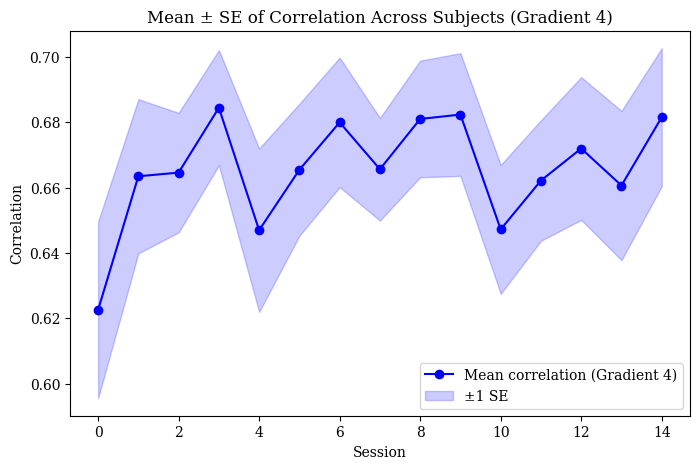

In [17]:
mean_corr = np.nanmean(corr_matrix, axis=0)
n_subjects_per_session = np.sum(~np.isnan(corr_matrix), axis=0)
stderr_corr = np.nanstd(corr_matrix, axis=0) / np.sqrt(n_subjects_per_session)
sessions = np.arange(corr_matrix.shape[1])

plt.figure(figsize=(8,5))
plt.plot(sessions, mean_corr,'o-', color='b', label=f'Mean correlation (Gradient {id_grad+1})')
plt.fill_between(sessions, mean_corr - stderr_corr, mean_corr + stderr_corr, color='b', alpha=0.2, label='±1 SE')
plt.xlabel('Session')
plt.ylabel('Correlation')
plt.title(f'Mean ± SE of Correlation Across Subjects (Gradient {id_grad+1})')
plt.legend()
plt.show()

In [18]:
from nilearn.datasets import fetch_atlas_schaefer_2018

# 200 parcels, 17-network version (has an Auditory network)
atl = fetch_atlas_schaefer_2018(n_rois=200, yeo_networks=17, resolution_mm=2)
# Decode any byte labels to str ---# labels[0] is "Background"
labels = [
    (lab.decode("utf-8") if isinstance(lab, (bytes, np.bytes_)) else str(lab))
    for lab in atl.labels
]

# 1-based indices (matching the labels list)
aud_1based = [i for i,lab in enumerate(labels) if "Aud" in lab or "Auditory" in lab or "TempPar_1" in lab or "TempPar_2" in lab]

# If your data array has already dropped the background (e.g., you did [1:]),
# convert to 0-based-without-background:
aud_0based_noBG = [i-1 for i in aud_1based if i > 0]

print("Auditory indices (1-based incl. background):", aud_1based)
print("Auditory indices (0-based after dropping background):", aud_0based_noBG)

Auditory indices (1-based incl. background): [20, 21, 24, 98, 99, 123, 124, 196, 197]
Auditory indices (0-based after dropping background): [19, 20, 23, 97, 98, 122, 123, 195, 196]


In [19]:
auditory_cortex = np.array([14,15,16,115,116,117])

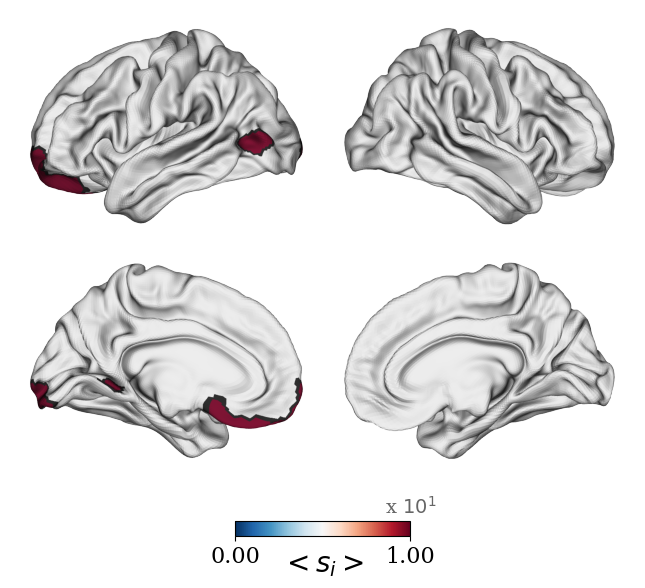

In [20]:
# def normal_view(current_nodestrength, edges=False, surftype='inflated',
#                xlabel=r'$<s_i> $', q_thresh=0.0, cmap='RdBu_r',
#                brightness=0.7, exp_form=True, parcellation=100,
#                vmin=None, vmax=None,graymap_rev=False,alpha_graymap=1.,parcellation_name='schaefer',center_cbar=False):

aud_vector = np.zeros(400)
##14,15
for idx in np.array([14,15,16,115,116,117]):
    aud_vector[idx] = 10
normal_view(aud_vector,parcellation=400,edges=True,surftype='midthickness');

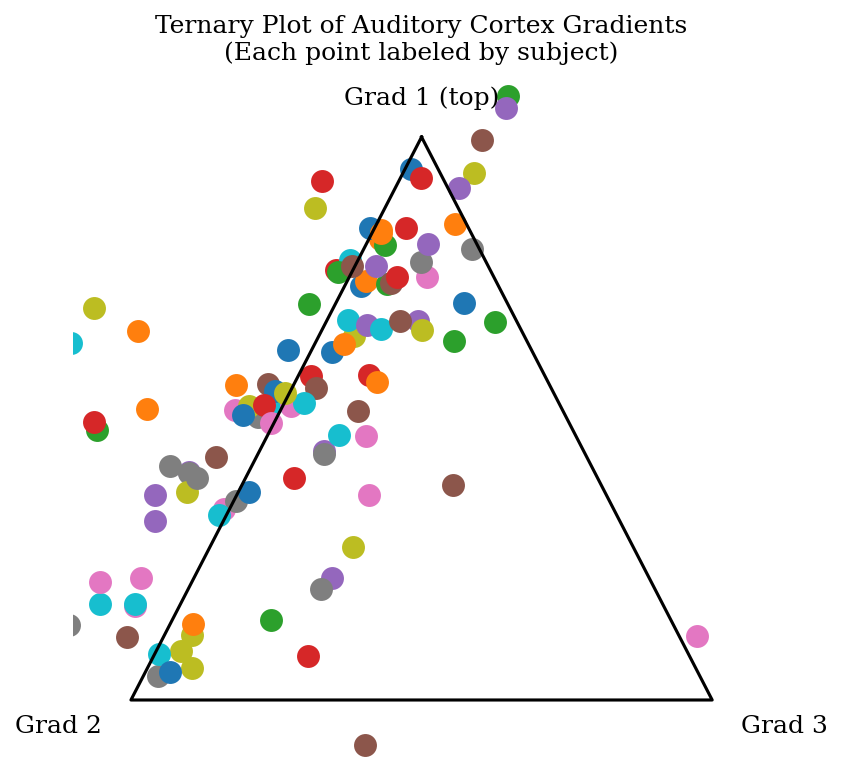

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Function to convert ternary to cartesian coordinates for plotting
def ternary_to_cartesian(a, b, c):
    # a: grad1 (top), b: grad2 (bottom left), c: grad3 (bottom right)
    # a+b+c should be 1
    x_cart = 0.5 * (2*c + a)
    y_cart = (np.sqrt(3)/2) * a
    return x_cart, y_cart

# Vertices of the triangle: top (Grad 1), bottom left (Grad 2), bottom right (Grad 3)
triangle = np.array([
    [0.5, np.sqrt(3)/2],   # Top (Grad 1)
    [0, 0],                # Bottom left (Grad 2)
    [1, 0],                # Bottom right (Grad 3)
    [0.5, np.sqrt(3)/2]    # Close the triangle
])

plt.figure(figsize=(6,6),dpi=150)
plt.plot(triangle[:,0], triangle[:,1], 'k-')

# Plot only the regions in the auditory_cortex for all subjects
# Assume: grads is a dict with subject IDs as keys, each value shape (1, 200, 3)
#         auditory_cortex is a numpy array of region indices (e.g., [14,15,16,115,116,117])
#         grads[subjID][0, idx, :] gives the 3 gradients for region idx in subject subjID
#         subjIDs is a list of all subject IDs

for subjID in grads.keys():
    for idx in auditory_cortex:
        x = grads[subjID][0, idx, 0]
        y = grads[subjID][0, idx, 1]
        z = grads[subjID][0, idx, 2]
        total = x + y + z
        if total != 0:
            x_norm, y_norm, z_norm = x/total, y/total, z/total
        else:
            x_norm, y_norm, z_norm = 0, 0, 0
        px, py = ternary_to_cartesian(x_norm, y_norm, z_norm)
        plt.scatter(px, py, s=100, label=subjID)
        # plt.text(px+0.01, py+0.01, subjID, fontsize=9)

plt.text(0.5, np.sqrt(3)/2 + 0.05, 'Grad 1 (top)', fontsize=12, ha='center')
plt.text(-0.05, -0.05, 'Grad 2', fontsize=12, ha='right')
plt.text(1.05, -0.05, 'Grad 3', fontsize=12, ha='left')
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, np.sqrt(3)/2 + 0.1)
plt.title('Ternary Plot of Auditory Cortex Gradients\n(Each point labeled by subject)')
plt.axis('off')
plt.show()

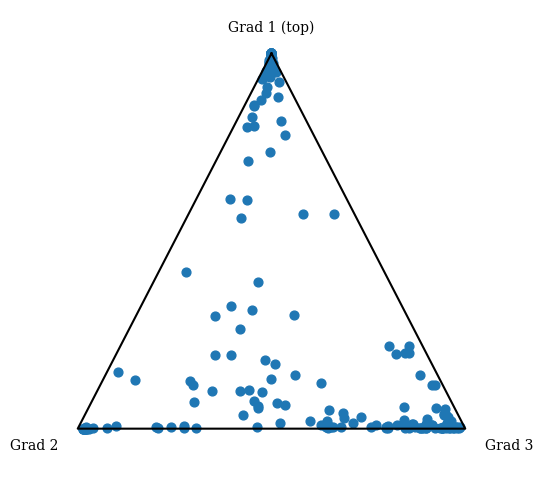

In [22]:
V = np.array([[grads[subjID][0, i, 0],
               grads[subjID][0, i, 1],
               grads[subjID][0, i, 2]] for i in range(200)], dtype=float)
V[~np.isfinite(V)] = 0.0

# softmax per row (numerically stable)
V = V - V.max(axis=1, keepdims=True)
A = np.exp(V); A /= A.sum(axis=1, keepdims=True)

x = 0.5*A[:,0] + A[:,2]
y = (np.sqrt(3)/2)*A[:,0]

tri = np.array([[0.5, np.sqrt(3)/2],[0,0],[1,0],[0.5, np.sqrt(3)/2]])
plt.figure(figsize=(6,6))
plt.plot(tri[:,0], tri[:,1], 'k-')
plt.scatter(x, y, s=40)
plt.text(0.5, np.sqrt(3)/2 + 0.05, 'Grad 1 (top)', ha='center')
plt.text(-0.05, -0.05, 'Grad 2', ha='right')
plt.text(1.05, -0.05, 'Grad 3', ha='left')
plt.xlim(-0.1, 1.1); plt.ylim(-0.1, np.sqrt(3)/2 + 0.1); plt.axis('off')
plt.show()

In [23]:
from brainspace.gradient import GradientMaps
from nilearn.connectome import ConnectivityMeasure

fc_mats = np.zeros((21, 15, 200, 200))
correlation_measure = ConnectivityMeasure(kind="correlation")
for subjID_idx, subjID in enumerate(sorted(data_all.keys())):
    for i in range(1, 16):
        if f'V{i:02d}_200' in data_all[subjID]:
            corr_mat = np.corrcoef(data_all[subjID][f'V{i:02d}_200'].T[:200, :])
            fc_mats[subjID_idx, i-1, :, :] = corr_mat

n_subjects = fc_mats.shape[0]
n_sessions = fc_mats.shape[1]

session_grads = {}
absent_subjects = {}

for sess in range(n_sessions):
    # Find subjects with nonzero data for this session
    nonzero_subjects = []
    zero_subjects = []
    for subjID_idx, subjID in enumerate(sorted(data_all.keys())):
        if not np.all(fc_mats[subjID_idx, sess] == 0):
            nonzero_subjects.append(subjID_idx)
        else:
            zero_subjects.append(subjID_idx)
    if len(nonzero_subjects) == 0:
        continue  # skip sessions with no data

    # Stack FCs for this session across available subjects
    sess_fc = [fc_mats[subjID_idx, sess] for subjID_idx in nonzero_subjects]
    sess_fc_stack = np.stack(sess_fc)

    # Compute reference gradients for this session (mean FC across subjects)
    gref = GradientMaps(kernel='cosine', approach='dm')
    gref.fit(sess_fc_stack.mean(axis=0))
    grefgrads = np.stack(gref.gradients_)

    # Compute gradients for each subject in this session, aligned to session reference
    # gm = GradientMaps(n_components=9, kernel='cosine', alignment="procrustes", random_state=0)
    # gm.fit(sess_fc, reference=gref.gradients_, sparsity=0.81)
    # Store gradients for this session, indexed by subject ID
    # session_grads[sess] = {sorted(data_all.keys())[subjID_idx]: grefgrads[i] for i, subjID_idx in enumerate(nonzero_subjects)}
    session_grads[sess] = grefgrads
    absent_subjects[sess] = [sorted(data_all.keys())[subjID_idx] for subjID_idx in zero_subjects]


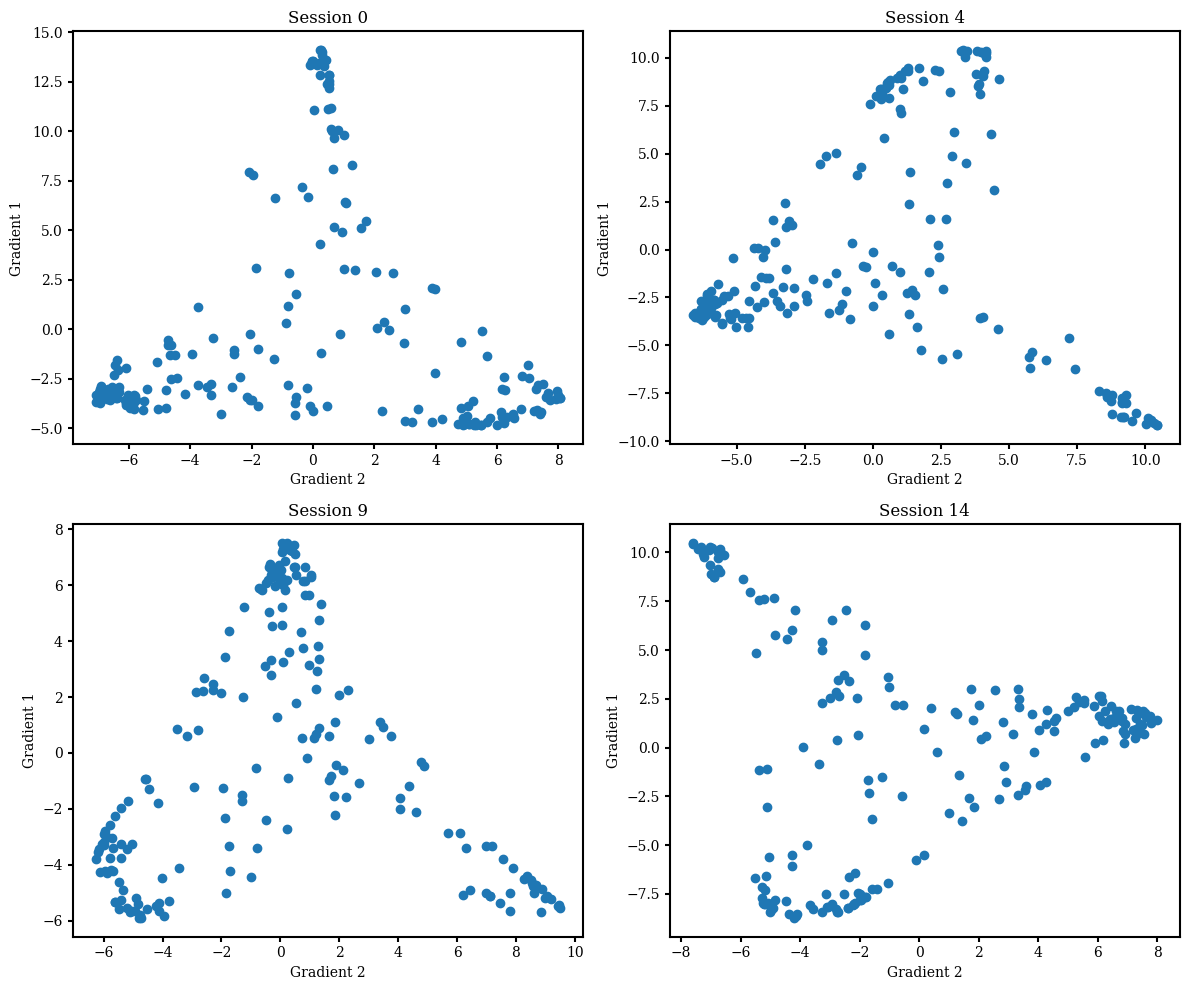

In [24]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
sessions = [0, 4, 9, 14]
titles = [f"Session {s}" for s in sessions]

for ax, sess, title in zip(axs.flat, sessions, titles):
    if sess in session_grads:
        ax.scatter(session_grads[sess][:,1], session_grads[sess][:,0])
        ax.set_title(title)
        ax.set_xlabel("Gradient 2")
        ax.set_ylabel("Gradient 1")
    else:
        ax.set_title(f"{title}\n(no data)")
        ax.axis('off')

plt.tight_layout()
plt.show()